## DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING
### Objective:
#### This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.
Dataset:
Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.
Tasks:


#### 1. Data Exploration and Preprocessing:
#### <ol>
Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).
Handle missing values as per the best practices (imputation, removal, etc.).
Apply scaling techniques to numerical features:
Standard Scaling
Min-Max Scaling
Discuss the scenarios where each scaling technique is preferred and why.


In [44]:
#load the dataset
import pandas as pd
df=pd.read_csv('adult_with_headers.csv')
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [45]:
#handle missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [46]:
#numerical features
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [47]:
# Display exploration results
summary_statistics = df.describe(include='all')
missing_values = df.isnull().sum()
data_types = df.dtypes
print("Summary Statistics:\n", summary_statistics)
print("Missing Values:\n", missing_values)
print("Data Types:\n", data_types)

Summary Statistics:
                  age workclass        fnlwgt education  education_num  \
count   32561.000000     32561  3.256100e+04     32561   32561.000000   
unique           NaN         9           NaN        16            NaN   
top              NaN   Private           NaN   HS-grad            NaN   
freq             NaN     22696           NaN     10501            NaN   
mean       38.581647       NaN  1.897784e+05       NaN      10.080679   
std        13.640433       NaN  1.055500e+05       NaN       2.572720   
min        17.000000       NaN  1.228500e+04       NaN       1.000000   
25%        28.000000       NaN  1.178270e+05       NaN       9.000000   
50%        37.000000       NaN  1.783560e+05       NaN      10.000000   
75%        48.000000       NaN  2.370510e+05       NaN      12.000000   
max        90.000000       NaN  1.484705e+06       NaN      16.000000   

             marital_status       occupation relationship    race    sex  \
count                 3256

In [48]:
#find the numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [49]:
#scaling techniques
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Standard Scaling
scaler = StandardScaler()
standard_scaled = scaler.fit_transform(df[numerical_features])
standard_scaled = pd.DataFrame(standard_scaled, columns=numerical_features)
standard_scaled.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [50]:
# Min-Max Scaling
scaler = MinMaxScaler()
minmax_scaled = scaler.fit_transform(df[numerical_features])
minmax_scaled = pd.DataFrame(minmax_scaled, columns=numerical_features)
minmax_scaled.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


In [51]:
# Scenarios where each scaling technique is preferred
print("Standard Scaling is preferred when the data is normally distributed, and the features have different units and scales.")
print("Min-Max Scaling is preferred when the data is not normally distributed, and the features have similar units and scales.")

#normally distributed data means the data is symmetrical and bell-shaped

Standard Scaling is preferred when the data is normally distributed, and the features have different units and scales.
Min-Max Scaling is preferred when the data is not normally distributed, and the features have similar units and scales.


#### 2. Encoding Techniques:
•	Apply One-Hot Encoding to categorical variables with less than 5 categories.
•	Use Label Encoding for categorical variables with more than 5 categories.
•	Discuss the pros and cons of One-Hot Encoding and Label Encoding.


In [52]:
# identify categorical features
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [53]:
#categorical features with less than 5 categories
less_than_5_categories = [col for col in categorical_features if df[col].nunique() < 5]
less_than_5_categories

['sex', 'income']

In [54]:
#one-hot encoding for categorical features with less than 5 categories
one_hot_encoded = pd.get_dummies(df[less_than_5_categories])
one_hot_encoded.head()

,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,False,True,True,False
1,False,True,True,False
2,False,True,True,False
3,False,True,True,False
4,True,False,True,False


In [55]:
#label encoding for categorical features with more than 5 categories
from sklearn.preprocessing import LabelEncoder
label_encoded = df.copy()
label_encoder = LabelEncoder()
for col in categorical_features:
    if col not in less_than_5_categories:
        label_encoded[col] = label_encoder.fit_transform(df[col])
label_encoded.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K
1,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K
2,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K
3,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K
4,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K


In [56]:
#combine the one-hot encoded and label encoded features
encoded_df = pd.concat([one_hot_encoded, label_encoded], axis=1)
encoded_df.head()

,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,False,True,True,False,39,7,77516,9,13,4,1,1,4,Male,2174,0,40,39,<=50K
1,False,True,True,False,50,6,83311,9,13,2,4,0,4,Male,0,0,13,39,<=50K
2,False,True,True,False,38,4,215646,11,9,0,6,1,4,Male,0,0,40,39,<=50K
3,False,True,True,False,53,4,234721,1,7,2,6,0,2,Male,0,0,40,39,<=50K
4,True,False,True,False,28,4,338409,9,13,2,10,5,2,Female,0,0,40,5,<=50K


In [57]:
# Pros and Cons of One-Hot Encoding and Label Encoding
print("One-Hot Encoding:")
print("Pros: It does not assume an ordinal relationship between categories, and it prevents the model from assigning incorrect weights to categories.")
print("Cons: It can lead to the curse of dimensionality, especially when the number of categories is high.")
print("\nLabel Encoding:")
print("Pros: It reduces the dimensionality of the data and can capture ordinal relationships between categories.")
print("Cons: It may introduce an ordinal relationship between categories where none exists, leading to incorrect model assumptions.")

One-Hot Encoding:
Pros: It does not assume an ordinal relationship between categories, and it prevents the model from assigning incorrect weights to categories.
Cons: It can lead to the curse of dimensionality, especially when the number of categories is high.

Label Encoding:
Pros: It reduces the dimensionality of the data and can capture ordinal relationships between categories.
Cons: It may introduce an ordinal relationship between categories where none exists, leading to incorrect model assumptions.


#### 3. Feature Engineering:
•	Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.
•	Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.


In [58]:
# Create new features
# Feature 1: Capital Income
encoded_df['capital_income'] = encoded_df['capital_gain'] - encoded_df['capital_loss']
# Feature 2: Work Hours per Week
encoded_df['work_hours_per_week'] = encoded_df['hours_per_week'] / encoded_df['education_num']
encoded_df.head()

,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,age,workclass,fnlwgt,education,education_num,marital_status,...,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_income,work_hours_per_week
0,False,True,True,False,39,7,77516,9,13,4,...,1,4,Male,2174,0,40,39,<=50K,2174,3.076923
1,False,True,True,False,50,6,83311,9,13,2,...,0,4,Male,0,0,13,39,<=50K,0,1.000000
2,False,True,True,False,38,4,215646,11,9,0,...,1,4,Male,0,0,40,39,<=50K,0,4.444444
3,False,True,True,False,53,4,234721,1,7,2,...,0,2,Male,0,0,40,39,<=50K,0,5.714286
4,True,False,True,False,28,4,338409,9,13,2,...,5,2,Female,0,0,40,5,<=50K,0,3.076923


In [59]:
# why we created these features
print("Capital Income: This feature captures the net capital gain or loss of an individual, which can provide additional insights into their financial status.")
print("Work Hours per Week: This feature normalizes the number of work hours by the education level of an individual, which can help in understanding the productivity or efficiency of work.")

Capital Income: This feature captures the net capital gain or loss of an individual, which can provide additional insights into their financial status.
Work Hours per Week: This feature normalizes the number of work hours by the education level of an individual, which can help in understanding the productivity or efficiency of work.


In [60]:
#skeewed numerical feature
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Identify skewed numerical features
skewed_features = encoded_df[numerical_features].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_features

#skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean which means the data is not normally distributed

capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
dtype: float64

In [61]:
# Apply log transformation to the skewed feature
df['capital_gain_log'] = np.log1p(df['capital_gain'])

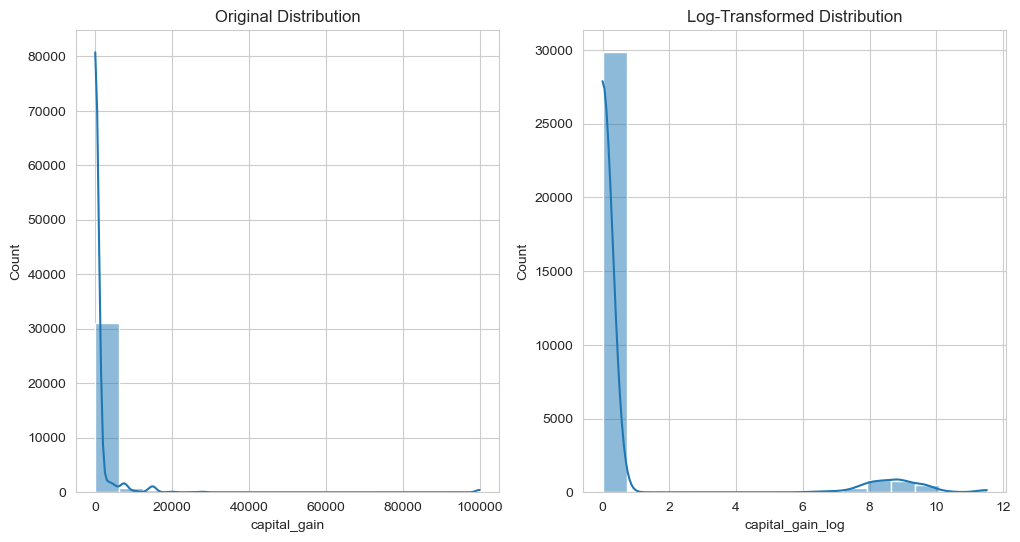

In [62]:
# Visualize the effect of log transformation
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['capital_gain'], kde=True)
plt.title('Original Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['capital_gain_log'], kde=True)
plt.title('Log-Transformed Distribution')
plt.show()


In [63]:
# Justification for log transformation
print("Log transformation is applied to the 'capital_gain' feature to reduce the skewness and make the distribution more symmetrical. This can help in improving the performance of models that assume normally distributed data.")

Log transformation is applied to the 'capital_gain' feature to reduce the skewness and make the distribution more symmetrical. This can help in improving the performance of models that assume normally distributed data.


#### 4. Feature Selection:
•	Use the Isolation Forest algorithm to identify and remove outliers. Discuss how outliers can affect model performance.
•	Apply the PPS (Predictive Power Score) to find and discuss the relationships between features. Compare its findings with the correlation matrix.


In [64]:
# Isolation Forest for outlier detection
from sklearn.ensemble import IsolationForest
# Identify outliers using Isolation Forest
iso_forest = IsolationForest(random_state=42, contamination=0.05)
df['outlier'] = iso_forest.fit_predict(df[numerical_features])
df['outlier'].value_counts()


outlier
 1    30933
-1     1628
Name: count, dtype: int64

In [65]:
# Remove outliers
df_cleaned = df[df['outlier'] == 1].copy()
df_cleaned.drop('outlier', axis=1, inplace=True)


In [66]:
# Discuss how outliers can affect model performance
print("Outliers can affect model performance by introducing noise and bias in the data, leading to incorrect parameter estimates and reduced model accuracy. Outliers can also impact the assumptions of linear models, such as the normality and homoscedasticity of residuals, resulting in unreliable predictions.")

Outliers can affect model performance by introducing noise and bias in the data, leading to incorrect parameter estimates and reduced model accuracy. Outliers can also impact the assumptions of linear models, such as the normality and homoscedasticity of residuals, resulting in unreliable predictions.


In [67]:
# correlation matrix
correlation_matrix = df_cleaned[numerical_features].corr()
correlation_matrix

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.079026,0.035963,0.093410,0.029835,0.094233
fnlwgt,-0.079026,1.000000,-0.039355,-0.012993,-0.011045,-0.021354
education_num,0.035963,-0.039355,1.000000,0.130080,0.045779,0.134755
capital_gain,0.093410,-0.012993,0.130080,1.000000,-0.032021,0.082962
capital_loss,0.029835,-0.011045,0.045779,-0.032021,1.000000,0.010101
hours_per_week,0.094233,-0.021354,0.134755,0.082962,0.010101,1.000000


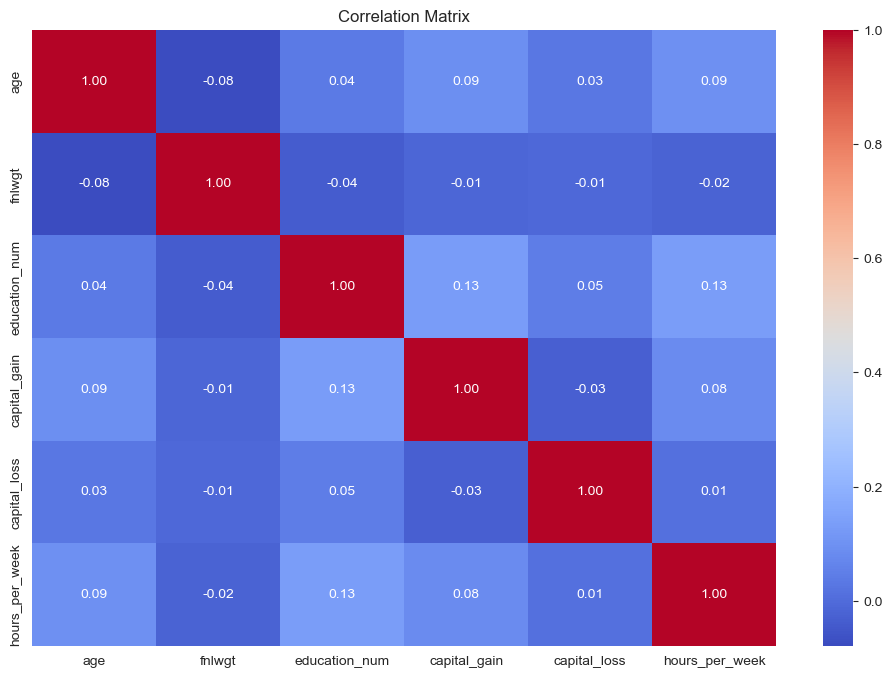

In [68]:
#plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


In [72]:
# PPS (Predictive Power Score) analysis
# pp-score is a metric that quantifies the relationship between two variables in a machine learning problem and can be used as an alternative to correlation analysis
import ppscore as pps
pps_matrix = pps.matrix(df_cleaned)
pps_matrix

ContextualVersionConflict: (pandas 2.2.3 (/opt/anaconda3/lib/python3.12/site-packages), Requirement.parse('pandas<2.0.0,>=1.0.0'), {'ppscore'})

In [75]:
#use mutual info classifier to find the relationship between features
from sklearn.feature_selection import mutual_info_classif
# Extract target variable
# Extract target variable
target = df_cleaned['']

# Select only numeric features
numeric_features = df_cleaned.select_dtypes(include=[np.number]).drop('income', axis=1)

# Calculate mutual information between features and target
mi_scores = mutual_info_classif(numeric_features, target)
mi_scores = pd.Series(mi_scores, name='MI Scores', index=numeric_features.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

KeyError: "['income'] not found in axis"

In [76]:
df_cleaned.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_log
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,7.684784
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0.000000
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0.000000
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0.000000
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0.000000
